Limpieza de data

In [1]:
import pandas as pd
import os

In [2]:
# Define tus rutas de archivos
csv_path = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\idrid\train.csv'
images_folder = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\idrid\train'

# Paso 1: Carga el archivo CSV original
try:
    df_original = pd.read_csv(csv_path)
except FileNotFoundError:
    print("Error: No se encontró el archivo CSV original. Revisa la ruta.")
    exit()

# Paso 2: Obtén la lista de IDs de las imágenes que realmente tienes
try:
    files_in_folder = os.listdir(images_folder)
    # Extrae solo los nombres de los archivos (sin extensión)
    image_ids_in_folder = {os.path.splitext(f)[0] for f in files_in_folder}
except FileNotFoundError:
    print("Error: No se encontró la carpeta de imágenes. Revisa la ruta.")
    exit()

# Paso 3: Filtra el DataFrame original
# Crea un nuevo DataFrame que solo incluya los IDs que existen en la carpeta
df_clean = df_original[df_original['image'].isin(image_ids_in_folder)]

# Paso 4: Guarda el DataFrame limpio en un nuevo archivo CSV
clean_csv_path = 'data_limpia'
df_clean.to_csv(clean_csv_path, index=False)

print(f"Limpieza completada. {len(df_clean)} de {len(df_original)} imágenes son válidas.")
print(f"El dataset limpio ha sido guardado en: {clean_csv_path}")

Limpieza completada. 413 de 413 imágenes son válidas.
El dataset limpio ha sido guardado en: data_limpia


grafico de cantidad de data en cada nivel

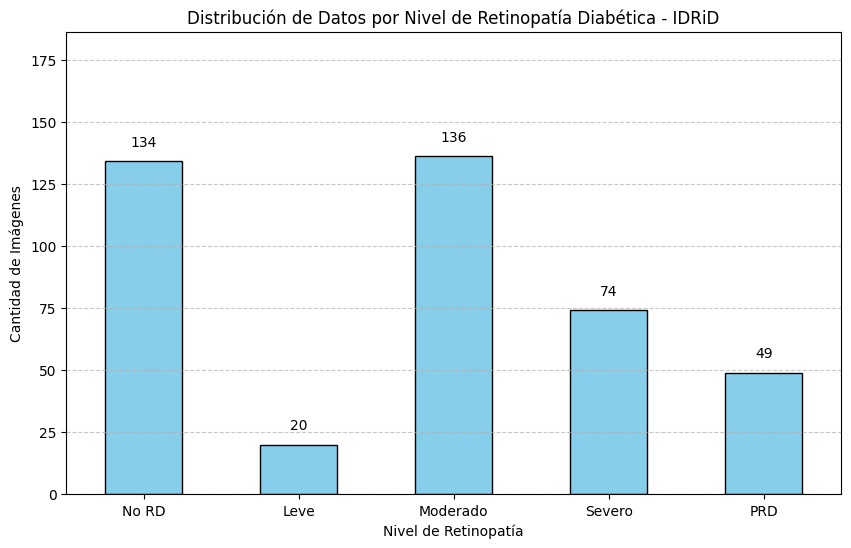

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Reemplaza la ruta de acceso con la ruta correcta que copiaste
# Asumo que estás usando el dataset que generó el gráfico más reciente (escala 0-500)
file_path = r'C:\Users\drive\OneDrive\Escritorio\data\datos_raw\idrid\train.csv'

try:
    # Carga el dataset
    df = pd.read_csv(file_path)

    # Cuenta las imágenes para cada nivel de retinopatía y ordena
    level_counts = df['level'].value_counts().sort_index()

    # --- AJUSTE CLAVE: RENOMBRAR LOS NIVELES ---
    # Diccionario para mapear los números (índice) a las etiquetas de texto
    level_map = {
        0: 'No RD',
        1: 'Leve',
        2: 'Moderado',
        3: 'Severo',
        4: 'PRD'
    }
    
    # Aplica el mapeo al índice de la serie de conteos
    level_counts = level_counts.rename(index=level_map)
    # ---------------------------------------------

    # Crea la figura y los ejes para el gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Genera el gráfico de barras y guarda las barras en una variable
    bars = level_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
    
    # --- Añadir las etiquetas de datos (números) sobre las barras ---
    # Desplazamiento adecuado para esta escala (0-500)
    VERTICAL_OFFSET = 5

    for bar in bars.patches:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2.0
        
        ax.text(
            x_pos, 
            height + VERTICAL_OFFSET, 
            f'{int(height)}',  
            ha='center', 
            va='bottom',
        )
    # ------------------------------------------------------------------

    # Configuración del gráfico
    # También actualizaremos el título para reflejar que es el dataset Messidor
    ax.set_title('Distribución de Datos por Nivel de Retinopatía Diabética - IDRiD')
    ax.set_xlabel('Nivel de Retinopatía')
    ax.set_ylabel('Cantidad de Imágenes')
    
    # Asegura que las etiquetas de texto (No DR, Mild, etc.) se vean horizontales
    plt.xticks(rotation=0) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajusta el límite superior del eje Y
    y_max = level_counts.max()
    ax.set_ylim(top=y_max + 50) 
    
    # Guarda y muestra el gráfico
    plt.savefig('distribucion_niveles_etiquetas_texto.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{file_path}'. Por favor, verifica la ruta de acceso.")